# NOAA-21 NUCAPS Profiles 1819 UTC 9 November 2025

dict_keys(['platform_name', 'platform_dir_name', 'platform_type', 'platform_id'])
<KeysViewHDF5 ['Num_Platforms', 'platform_name', 'platform_dir_name', 'platform_type', 'platform_id', '20251109']>
Temp:  [[   195.29688    204.21875    218.      ... -32768.      -32768.
  -32768.     ]
 [   192.04688    201.15625    215.60938 ... -32768.      -32768.
  -32768.     ]
 [   186.625      194.1875     209.      ... -32768.      -32768.
  -32768.     ]
 ...
 [   200.40625    208.26562    220.04688 ... -32768.      -32768.
  -32768.     ]
 [   201.46875    209.59375    221.4375  ... -32768.      -32768.
  -32768.     ]
 [   201.39062    209.01562    220.625   ... -32768.      -32768.
  -32768.     ]] (1105, 100)
Press:  [[ 1.6000e-02  3.8000e-02  7.7000e-02 ... -3.2768e+04 -3.2768e+04
  -3.2768e+04]
 [ 1.6000e-02  3.8000e-02  7.7000e-02 ... -3.2768e+04 -3.2768e+04
  -3.2768e+04]
 [ 1.6000e-02  3.8000e-02  7.7000e-02 ... -3.2768e+04 -3.2768e+04
  -3.2768e+04]
 ...
 [ 1.6000e-02  3.8000e-02  7.7

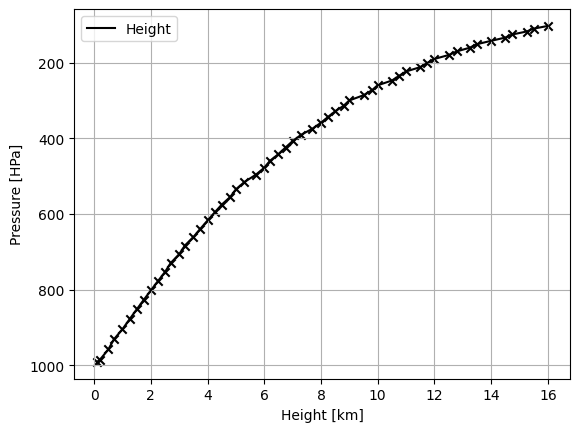

Height: [ 0.1   0.2   0.5   0.7   1.    1.25  1.5   1.75  2.    2.25  2.5   2.7
  3.    3.2   3.5   3.75  4.    4.25  4.5   4.8   5.    5.3   5.7   6.
  6.2   6.5   6.75  7.    7.3   7.7   8.    8.25  8.5   8.8   9.    9.5
  9.8  10.   10.5  10.75 11.   11.5  11.75 12.   12.5  12.8  13.25 13.5
 14.   14.5  14.75 15.25 15.5  16.  ]
Pressure: [991.5 986.1 958.6 931.5 904.9 878.6 852.8 827.4 802.4 777.8 753.6 729.9
 706.6 683.7 661.2 639.1 617.5 596.3 575.5 555.2 535.2 515.7 496.6 478.
 459.7 441.9 424.5 407.5 390.9 374.7 359.  343.6 328.7 314.1 300.  286.3
 272.9 260.  247.4 235.2 223.4 212.  201.  190.3 180.  170.1 160.5 151.3
 142.4 133.8 125.6 117.8 110.2 103. ]
Humidity: [ 55.78108597  56.19614029  55.88755798  61.39086533  74.16737366
  90.59981537 102.04044342  99.95069122  91.01191711  82.65492249
  71.0582428   61.11708832  54.16358566  44.28779221  37.47564316
  34.6954689   30.69246483  28.74493217  29.08777046  28.00951576
  27.8363018   29.60045624  32.14207458  34.55699539  

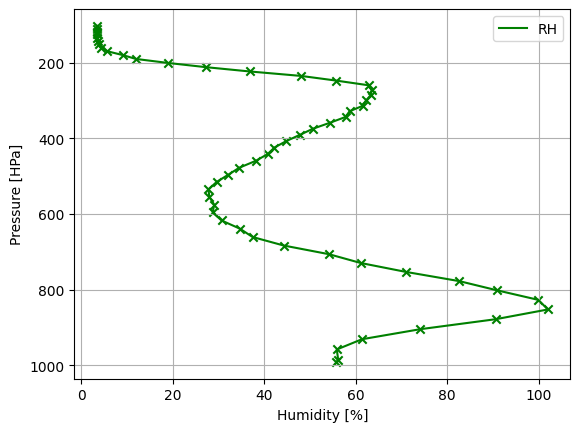

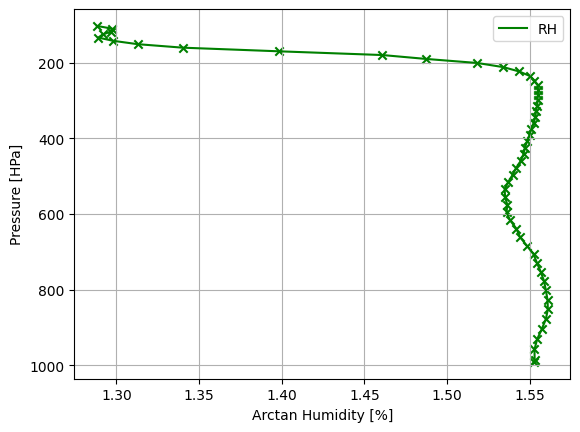

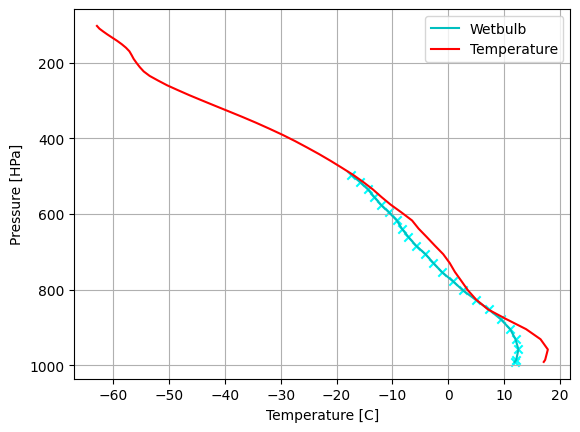

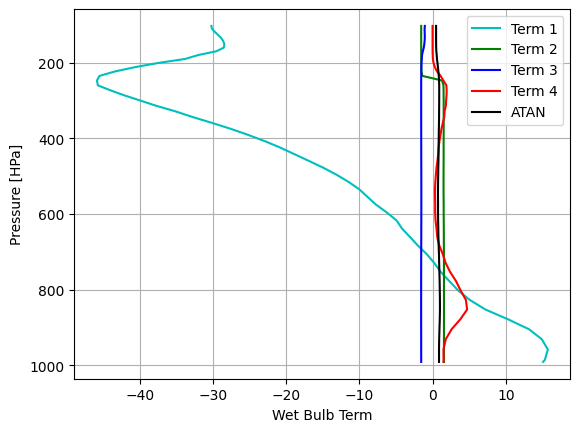

PUP idx =  (array([8]),)
PLO idx =  (array([2]),)

Gamma =  [9.53125]
Conditional Instability
Theta-e Gamma =  [-5.28708903]
Theta-e lapse rate is negative: potential instability
Tv Gamma =  [10.074382]
Wetbulb Gamma =  [6.61546305]
Potential Instability
{'hght': array([  100.,   200.,   500.,   700.,  1000.,  1250.,  1500.,  1750.,
        2000.,  2250.,  2500.,  2700.,  3000.,  3200.,  3500.,  3750.,
        4000.,  4250.,  4500.,  4800.,  5000.,  5300.,  5700.,  6000.,
        6200.,  6500.,  6750.,  7000.,  7300.,  7700.,  8000.,  8250.,
        8500.,  8800.,  9000.,  9500.,  9800., 10000., 10500., 10750.,
       11000., 11500., 11750., 12000., 12500., 12800., 13250., 13500.,
       14000., 14500., 14750., 15250., 15500., 16000.]), 'pres': array([991.5, 986.1, 958.6, 931.5, 904.9, 878.6, 852.8, 827.4, 802.4,
       777.8, 753.6, 729.9, 706.6, 683.7, 661.2, 639.1, 617.5, 596.3,
       575.5, 555.2, 535.2, 515.7, 496.6, 478. , 459.7, 441.9, 424.5,
       407.5, 390.9, 374.7, 359. , 

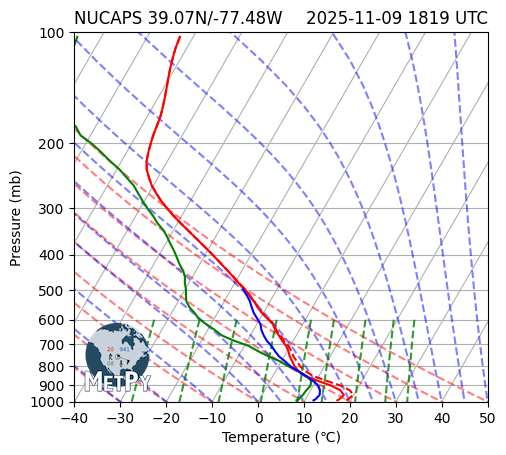

In [17]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from netCDF4 import Dataset
import h5py
from six import StringIO
import metpy.calc as mpcalc
from metpy.cbook import get_test_data
from metpy.plots import add_metpy_logo, SkewT
from metpy.units import units

'''
NOAA-21 NUCAPS Profile at 1819 UTC 9 November 2025 39.07N/-77.48W Retrieval #
'''

def read_nprovs_names(ncf):
    nc_fid = Dataset(ncf, 'r')
    names = nc_fid.variables.keys()
    nc_fid.close()
    return names

nprovs_ret_file = 'nprovs_20251109.nc'
names = read_nprovs_names(nprovs_ret_file)
print(names)

# Open file.
FILE_NAME = 'nprovs_20251109.nc'
temperature = '/20251109/NUCAPS_NOAA21_610/temperature'
pressure = '/20251109/NUCAPS_NOAA21_610/pressure'
humidity = '/20251109/NUCAPS_NOAA21_610/relative_humidity'
qf = '/20251109/NUCAPS_NOAA21_610/retrieval_quality_flag'
LATITUDE = '/20251109/NUCAPS_NOAA21_610/latitude'
LONGITUDE = '/20251109/NUCAPS_NOAA21_610/longitude'
time = '/20251109/NUCAPS_NOAA21_610/time'

with h5py.File(FILE_NAME, mode='r') as f:
    # List available datasets.
    print(f.keys())

    # Read dataset.
    temp = f[temperature]
    temp_ret = temp[:,:]
    print("Temp: ",temp_ret,temp_ret.shape)
    press = f[pressure]
    press_ret = press[:,:]
    print("Press: ",press_ret,press_ret.shape)
    RH = f[humidity]
    RH_ret = RH[:,:]
    print("Humidity: ",RH_ret,RH_ret.shape)
    rqf = f[qf]
    retqual = rqf[1048]
    if (retqual == 0):
        print("Retrieval value = 0: Accepted")
    elif (retqual == 1):
        print("Retrieval value = 1: rejected physical")
    elif (retqual == 2):
        print("Retrieval value = 2: rejected MIT")
    elif (retqual == 9):
        print("Retrieval value = 9: rejected physical and MIT")
    else:
        print("Retrieval rejected")        
    latitude = f[LATITUDE]
    for i, name in enumerate(latitude):
        if name > 37 and name < 40:
            print(f"Index {i}: {name}")
    lat = latitude[1048]
    print("Latitude: ",lat)
    longitude = f[LONGITUDE]
    for i, name in enumerate(longitude):
        if name > -79 and name < -75:
            print(f"Index {i}: {name}")
    lon = longitude[1048]
    print("Longitude: ",lon)
    time = f[time]
    for i, name in enumerate(time):
        if name > 173000.0 and name < 183000.0:
            print(f"Index {i}: {name}")
    time_ret = time[1048]
    print("Time: ",time_ret)    

print("Pressure: ",press_ret,press_ret.shape)
press = press_ret[1048,43:97]
print("Pressure retrieval: ",press,press.shape)
press = press[::-1]
print("Pressure: ",press,press.shape)

print("Temperature: ",temp_ret,temp_ret.shape)
temp = temp_ret[1048,43:97]
print("Temperature retrieval: ",temp,temp.shape)
temp = temp[::-1]
print("Temperature: ",temp,temp.shape)

print("Humidity: ", RH_ret)
RH = RH_ret[1048,43:97]
print("Humidity retrieval: ",RH,RH.shape)
RH_pct = RH[::-1]
print("Humidity: ",RH_pct,RH_pct.shape)
temperature_c = temp - 273.15
dewpoint_c = 243.04*((np.log(RH_pct/100))+((17.625*temperature_c)/(243.04+temperature_c)))/(17.625-(np.log(RH_pct/100))-((17.625*temperature_c)/(243.04+temperature_c)))
dewpoint = dewpoint_c + 273.15
print(dewpoint,dewpoint.shape)
height_km = np.array([0.1,0.2,0.5,0.7,1.0,1.25,1.5,1.75,2.0,2.25,2.5,2.7,3.0,3.2,3.5,3.75,4.0,4.25,4.5,4.8,5.0,5.3,5.7,6.0,
                      6.2,6.5,6.75,7.0,7.3,7.7,8.0,8.25,8.5,8.8,9.0,9.5,9.8,10.0,10.5,10.75,11.0,11.5,11.75,12.0,12.5,
                      12.8,13.25,13.5,14.0,14.5,14.75,15.25,15.5,16.0])
height_m = height_km * 1000
print(height_m,len(height_m))
height_km = height_m/1000
print(height_km,len(height_km))
pressure_pa = press
pressure_pa_r = np.flip(pressure_pa)
idx_500hpa = np.where(press == 496.6)
print("500 Hpa idx = ", idx_500hpa)
L_vapor = 2500

thetae = (273.15 + temperature_c)*((1000/pressure_pa)**0.286)+(3 * (RH_pct * (3.884266 * 10**
         ((7.5 * temperature_c)/(237.7 + temperature_c)))/100))
print("Theta-e: ", thetae, thetae.shape)
RH_pct = np.float64(RH_pct)
wetbulb = temperature_c*(np.arctan(0.151977*((RH_pct+8.313659)**0.5))) + (np.arctan(temperature_c+RH_pct)) - (np.arctan(RH_pct-1.676331))+((0.00391838*(RH_pct**1.5))*(np.arctan(0.023101*RH_pct))) - 4.686035
wetbulb[23:54] = np.nan
print("Wet bulb: ", wetbulb, wetbulb.shape)
WBD = temperature_c - wetbulb
satmixrat = (6.11*(10**((7.5*temperature_c)/(237.7+temperature_c))))/1000
print("Sat_mix_ratio = ",satmixrat)
mixrat = (6.11*(10**((7.5*dewpoint_c)/(237.7+dewpoint_c))))/1000
print("Mix_ratio = ",mixrat)
thetaw = thetae - (L_vapor*mixrat)
tempvirt = temp*(1+(0.61*(mixrat)))
tempvirt_c = tempvirt - 273.15
print("Virtual Temperature (C) = ",tempvirt_c)
tempvirt_exc = tempvirt_c - temperature_c

WB_term1 = temperature_c*(np.arctan(0.151977*((RH_pct+8.313659)**0.5)))
WB_term2 = np.arctan(temperature_c+RH_pct)
WB_term3 = -1*(np.arctan(RH_pct-1.676331))
WB_term4 = (0.00391838*(RH_pct**1.5))*(np.arctan(0.023101*RH_pct))
ATAN_term1 = (np.arctan(0.151977*((RH_pct+8.313659)**0.5)))

plt.plot(height_km, pressure_pa, color='black', label='Height')
plt.scatter(height_km, pressure_pa, color='black', marker='x')
plt.gca().invert_yaxis()
plt.xlabel("Height [km]")
plt.ylabel("Pressure [HPa]")
plt.legend()
plt.grid()
plt.show()
print("Height:", height_km)
print("Pressure:", pressure_pa)
print("Humidity:", RH_pct)

ATAN_RH = np.arctan(RH_pct)

plt.plot(RH_pct, pressure_pa, 'g-', label='RH')
plt.scatter(RH_pct, pressure_pa, color='green', marker='x')
plt.gca().invert_yaxis()
plt.xlabel("Humidity [%]")
plt.ylabel("Pressure [HPa]")
plt.legend()
plt.grid()
plt.show()

plt.plot(ATAN_RH, pressure_pa, 'g-', label='RH')
plt.scatter(ATAN_RH, pressure_pa, color='green', marker='x')
plt.gca().invert_yaxis()
plt.xlabel("Arctan Humidity [%]")
plt.ylabel("Pressure [HPa]")
plt.legend()
plt.grid()
plt.show()

plt.plot(wetbulb, pressure_pa, 'c-', label='Wetbulb')
plt.scatter(wetbulb, pressure_pa, color='cyan', marker='x')
plt.plot(temperature_c, pressure_pa, 'r-', label='Temperature')
plt.gca().invert_yaxis()
plt.xlabel("Temperature [C]")
plt.ylabel("Pressure [HPa]")
plt.legend()
plt.grid()
plt.show()

plt.plot(WB_term1, pressure_pa, 'c-', label='Term 1')
plt.plot(WB_term2, pressure_pa, 'g-', label='Term 2')
plt.plot(WB_term3, pressure_pa, 'b-', label='Term 3')
plt.plot(WB_term4, pressure_pa, 'r-', label='Term 4')
plt.plot(ATAN_term1, pressure_pa, 'k-', label='ATAN')
plt.gca().invert_yaxis()
plt.xlabel("Wet Bulb Term")
plt.ylabel("Pressure [HPa]")
plt.legend()
plt.grid()
plt.show()

idx_pup = np.where(press == 802.4)
idx_plo = np.where(press == 958.6)
print("PUP idx = ", idx_pup)
print("PLO idx = ", idx_plo)
Z_upper = height_km[idx_pup]
Z_lower = height_km[idx_plo]
T_sfc = temp[idx_plo]
T_top = temp[idx_pup]
Te_sfc = thetae[idx_plo]
Te_top = thetae[idx_pup]
Tv_sfc = tempvirt_c[idx_plo]
Tv_top = tempvirt_c[idx_pup]
wetbulb_sfc = wetbulb[idx_plo]
wetbulb_top = wetbulb[idx_pup]
thetaw_sfc = thetaw[idx_pup]
delta_z = 1500
delta_zkm = 1.5
gamma = (T_sfc - T_top)/(delta_zkm)
gamma_Te = (Te_sfc - Te_top)/(Z_lower - Z_upper)
gamma_Tv = (Tv_sfc - Tv_top)/(delta_zkm)
gamma_wb = (wetbulb_sfc - wetbulb_top)/(delta_zkm)

print("")
print("Gamma = ", gamma)
if gamma > 4.8 and gamma <= 9.8:
    print("Conditional Instability") 
elif gamma > 9.8:
    print("Absolute Instability")
print("Theta-e Gamma = ", gamma_Te)
if gamma_Te < 0:
    print("Theta-e lapse rate is negative: potential instability")    
print("Tv Gamma = ", gamma_Tv)
print("Wetbulb Gamma = ", gamma_wb)
if gamma_wb > 4.8:
    print("Potential Instability")    
 
mydata=dict(zip(('hght','pres','temp','dwpt','thtae','thetaw','wetbulb','depression','tempvirt','tempvirt_exc'),(height_m,pressure_pa,temperature_c,dewpoint_c,thetae,thetaw,wetbulb,WBD,tempvirt_c,tempvirt_exc)))
print(mydata)
df_ret = pd.DataFrame.from_dict(mydata)
print(df_ret)
wdir = []
wspd = []
wval = -9999.00
data_len = len(df_ret)
print("DF Length = ", data_len)
for i in range(data_len):
    wdir.append(wval)
    wspd.append(wval)
print("wdir, wspd: ", wdir, wspd)
data_sharppy=dict(zip(('pres','hght','temp','dwpt','wetbulb'),(pressure_pa, height_m, temperature_c, dewpoint_c, wetbulb)))
print(data_sharppy)
df_sharppy = pd.DataFrame.from_dict(data_sharppy)
print(df_sharppy)
df_sharppy = df_sharppy[['pres', 'hght', 'temp', 'dwpt', 'wetbulb']]
print(df_sharppy)
df_sharppy_file = df_sharppy[['pres', 'hght', 'temp', 'dwpt']]
print(df_sharppy_file)
df_sharppy_wind = df_sharppy_file.assign(wdir = wdir, wspd = wspd)
print(df_sharppy_wind)
print("")
print("Sharppy formatted retrieval: ")
print("")
print(df_sharppy_wind.to_string(header=False, index=False, formatters={"pres": "  {:.2f},  ".format, "hght": "{:.2f},  ".format,
                                                                       "temp": "{:.2f},  ".format, "dwpt": "{:.2f},  ".format,
                                                                       "wdir": "{:.2f},  ".format, "wspd": "{:.2f} ".format}))
print("")
print("Sounding profile with virtual temperature")
print("")
data_sharppy=dict(zip(('pres','hght','tempvirt','dwpt','wetbulb'),(pressure_pa, height_m, tempvirt_c, dewpoint_c, wetbulb)))
print(data_sharppy)
df_sharppy = pd.DataFrame.from_dict(data_sharppy)
print(df_sharppy)
df_sharppy = df_sharppy[['pres', 'hght', 'tempvirt', 'dwpt', 'wetbulb']]
print(df_sharppy)
df_sharppy_file = df_sharppy[['pres', 'hght', 'tempvirt', 'dwpt']]
print(df_sharppy_file)
df_sharppy_wind =df_sharppy_file.assign(wdir = wdir, wspd = wspd)
print(df_sharppy_wind)
print("")
print("Sharppy formatted retrieval: ")
print("")
print(df_sharppy_wind.to_string(header=False, index=False, formatters={"pres": "  {:.2f},  ".format, "hght": "{:.2f},  ".format,
                                                                       "tempvirt": "{:.2f},  ".format, "dwpt": "{:.2f},  ".format,
                                                                       "wdir": "{:.2f},  ".format, "wspd": "{:.2f} ".format}))
print("")

mydata=dict(zip(('hght','pres','temp','dwpt','thtae','thetaw','wetbulb','depression','tempvirt','tempvirt_exc'),(height_m,pressure_pa,temperature_c,dewpoint_c,thetae,thetaw,wetbulb,WBD,tempvirt_c,tempvirt_exc)))
print(mydata)
df_ret = pd.DataFrame.from_dict(mydata)
print(df_ret)
wdir = []
wspd = []
wval = 0
data_len = len(df_ret)
print("DF Length = ", data_len)
for i in range(data_len):
    wdir.append(wval)
    wspd.append(wval)
print("wdir, wspd: ", wdir, wspd)
data_sharppy=dict(zip(('pres','hght','temp','dwpt','wetbulb'),(pressure_pa, height_m, temperature_c, dewpoint_c, wetbulb)))
print(data_sharppy)
df_sharppy = pd.DataFrame.from_dict(data_sharppy)
print(df_sharppy)
df_sharppy = df_sharppy[['pres', 'hght', 'temp', 'dwpt', 'wetbulb']]
print(df_sharppy)
df_sharppy_T = df_sharppy[['pres', 'hght', 'temp', 'dwpt', 'wetbulb']]
print(df_sharppy_T)
df_sharppy_file = df_sharppy[['pres', 'hght', 'temp', 'dwpt']]
print(df_sharppy_file)
df_sharppy_wind =df_sharppy_file.assign(wdir = wdir, wspd = wspd)
print(df_sharppy_wind)
print("")
print("Sharppy formatted retrieval: ")
print("")
print(df_sharppy_wind.to_string(header=False, index=False, formatters={"pres": "  {:.2f},  ".format, "hght": "{:.2f},  ".format,
                                                                       "temp": "{:.2f},  ".format, "dwpt": "{:.2f},  ".format,
                                                                       "wdir": "{:.2f},  ".format, "wspd": "{:.2f} ".format}))

print("")
print("Sounding profile with virtual temperature")
print("")
data_sharppy=dict(zip(('pres','hght','tempvirt','dwpt','wetbulb'),(pressure_pa, height_m, tempvirt_c, dewpoint_c, wetbulb)))
print(data_sharppy)
df_sharppy = pd.DataFrame.from_dict(data_sharppy)
print(df_sharppy)
df_sharppy = df_sharppy[['pres', 'hght', 'tempvirt', 'dwpt', 'wetbulb']]
print(df_sharppy)
df_sharppy_Tv = df_sharppy[['pres', 'hght', 'tempvirt', 'dwpt', 'wetbulb']]
print(df_sharppy_Tv)
df_sharppy_file = df_sharppy[['pres', 'hght', 'tempvirt', 'dwpt']]
print(df_sharppy_file)
df_sharppy_wind =df_sharppy_file.assign(wdir = wdir, wspd = wspd)
print(df_sharppy_wind)
print("")
print("Sharppy formatted retrieval: ")
print("")
print(df_sharppy_wind.to_string(header=False, index=False, formatters={"pres": "  {:.2f},  ".format, "hght": "{:.2f},  ".format,
                                                                       "tempvirt": "{:.2f},  ".format, "dwpt": "{:.2f},  ".format,
                                                                       "wdir": "{:.2f},  ".format, "wspd": "{:.2f} ".format}))
print("")
P_level_upper = pressure_pa[idx_pup]
P_level_lower = pressure_pa[idx_plo]
Z_upper = height_km[idx_pup]
Z_lower = height_km[idx_plo]
T_upper = temperature_c[idx_pup]
T_lower = temperature_c[idx_plo]
Tv_upper = tempvirt_c[idx_pup]
Tv_lower = tempvirt_c[idx_plo]
TD_upper = dewpoint_c[idx_pup]
TD_lower = dewpoint_c[idx_plo]
CAPE = 0

print("Dry bulb temperature calculation")
print("")
def MWPI(P_level_upper, P_level_lower, Z_upper, Z_lower, T_upper, T_lower, TD_upper, TD_lower, CAPE):
        gamma = (T_lower - T_upper)/(Z_upper - Z_lower)
        print("Gamma = ", gamma)
        DD_upper = T_upper - TD_upper
        print("DD upper = ", DD_upper)
        DD_lower = T_lower - TD_lower
        print("DD lower = ", DD_lower)
        DDD = DD_lower - DD_upper
        print("Delta DD = ", DDD)
        MWPI = (CAPE/1000) + (gamma/5) + (DDD/5)
        WGP = (0.35435365777 * (MWPI**2)) + (1.2959855*MWPI) + 33.8176788
        return MWPI, WGP
MWPI, WGP = MWPI(P_level_upper, P_level_lower, Z_upper, Z_lower, T_upper, T_lower, TD_upper, TD_lower, CAPE)    
print("")
print("MWPI = ", MWPI)
print("MWPI WGP (kt) = ", WGP)
print("")
print("Virtual temperature calculation")
print("")
def MWPI_Tv(P_level_upper, P_level_lower, Z_upper, Z_lower, Tv_upper, Tv_lower, TD_upper, TD_lower, CAPE):
        gamma = (Tv_lower - Tv_upper)/(Z_upper - Z_lower)
        print("Gamma = ", gamma)
        DD_upper = Tv_upper - TD_upper
        print("DD upper = ", DD_upper)
        DD_lower = Tv_lower - TD_lower
        print("DD lower = ", DD_lower)
        DDD = DD_lower - DD_upper
        print("Delta DD = ", DDD)
        MWPI_Tv = (CAPE/1000) + (gamma/5) + (DDD/5)
        WGP_Tv = (0.35435365777 * (MWPI_Tv**2)) + (1.2959855*MWPI_Tv) + 33.8176788
        return MWPI_Tv, WGP_Tv
MWPI_Tv, WGP_Tv  = MWPI_Tv(P_level_upper, P_level_lower, Z_upper, Z_lower, Tv_upper, Tv_lower, TD_upper, TD_lower, CAPE)    
print("")
print("MWPI from Virtual Temperature:")
print("MWPI = ", MWPI_Tv)
print("MWPI WGP (kt) = ", WGP_Tv)

p = df_sharppy['pres'].values * units.hPa
T = df_sharppy_T['temp'].values * units.degC
Tv = df_sharppy_Tv['tempvirt'].values * units.degC
Tw = df_sharppy['wetbulb'].values * units.degC
Td = df_sharppy['dwpt'].values * units.degC

skew = SkewT()

# Plot the data using normal plotting functions, in this case using
# log scaling in Y, as dictated by the typical meteorological plot
skew.plot(p, T, 'r')
skew.plot(p, Tv, color='red', linestyle='--')
skew.plot(p, Td, 'g')
skew.plot(p, Tw, 'b')

# Set some better labels than the default
skew.ax.set_xlabel('Temperature (\N{DEGREE CELSIUS})')
skew.ax.set_ylabel('Pressure (mb)')

# Add the relevant special lines
skew.plot_dry_adiabats()
skew.plot_moist_adiabats()
skew.plot_mixing_lines()
skew.ax.set_ylim(1000, 100)

# Add the MetPy logo!
fig = plt.gcf()
add_metpy_logo(fig, 80, 60)

# Add some titles
plt.title('NUCAPS 39.07N/-77.48W', loc='left')
plt.title('2025-11-09 1819 UTC', loc='right')
plt.savefig('skewt_noaa21_1109_1819_mp.png', bbox_inches='tight') # saves the plot to the disk.
plt.show()

dict_keys(['platform_name', 'platform_dir_name', 'platform_type', 'platform_id'])
<KeysViewHDF5 ['Num_Platforms', 'platform_name', 'platform_dir_name', 'platform_type', 'platform_id', '20251109']>
Temp:  [[   196.78125    205.76562    219.71875 ... -32768.      -32768.
  -32768.     ]
 [   195.46875    204.5        218.78125 ... -32768.      -32768.
  -32768.     ]
 [   187.98438    195.51562    210.25    ... -32768.      -32768.
  -32768.     ]
 ...
 [   201.14062    209.         220.78125 ... -32768.      -32768.
  -32768.     ]
 [   199.32812    207.60938    219.53125 ... -32768.      -32768.
  -32768.     ]
 [   202.54688    210.125      221.75    ... -32768.      -32768.
  -32768.     ]] (1105, 100)
Press:  [[ 1.6000e-02  3.8000e-02  7.7000e-02 ... -3.2768e+04 -3.2768e+04
  -3.2768e+04]
 [ 1.6000e-02  3.8000e-02  7.7000e-02 ... -3.2768e+04 -3.2768e+04
  -3.2768e+04]
 [ 1.6000e-02  3.8000e-02  7.7000e-02 ... -3.2768e+04 -3.2768e+04
  -3.2768e+04]
 ...
 [ 1.6000e-02  3.8000e-02  7.7

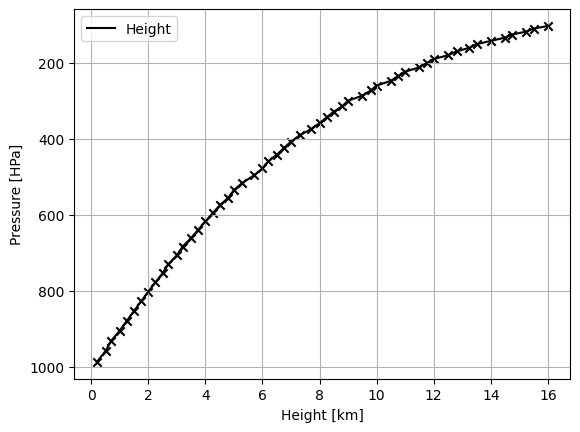

Height: [ 0.2   0.5   0.7   1.    1.25  1.5   1.75  2.    2.25  2.5   2.7   3.
  3.2   3.5   3.75  4.    4.25  4.5   4.8   5.    5.3   5.7   6.    6.2
  6.5   6.75  7.    7.3   7.7   8.    8.25  8.5   8.8   9.    9.5   9.8
 10.   10.5  10.75 11.   11.5  11.75 12.   12.5  12.8  13.25 13.5  14.
 14.5  14.75 15.25 15.5  16.  ]
Pressure: [987.2 958.6 931.5 904.9 878.6 852.8 827.4 802.4 777.8 753.6 729.9 706.6
 683.7 661.2 639.1 617.5 596.3 575.5 555.2 535.2 515.7 496.6 478.  459.7
 441.9 424.5 407.5 390.9 374.7 359.  343.6 328.7 314.1 300.  286.3 272.9
 260.  247.4 235.2 223.4 212.  201.  190.3 180.  170.1 160.5 151.3 142.4
 133.8 125.6 117.8 110.2 103. ]


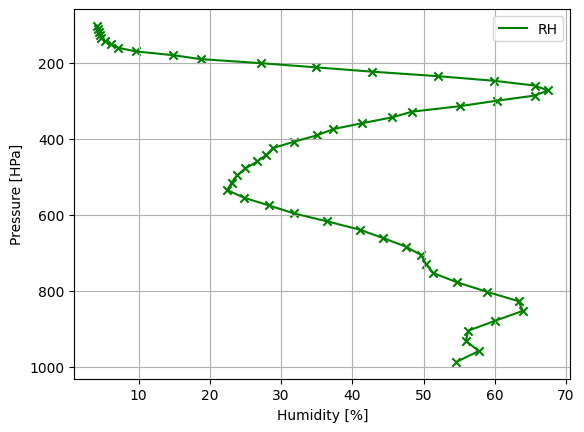

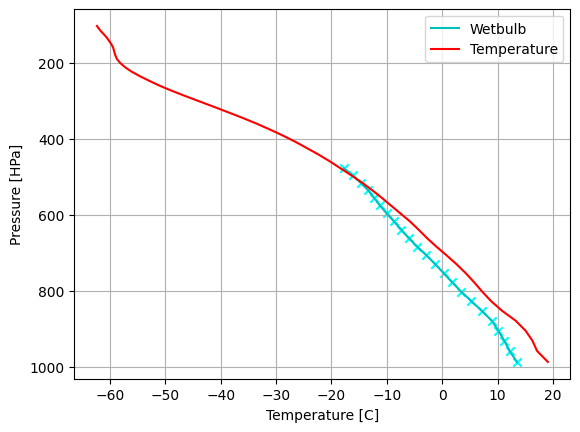

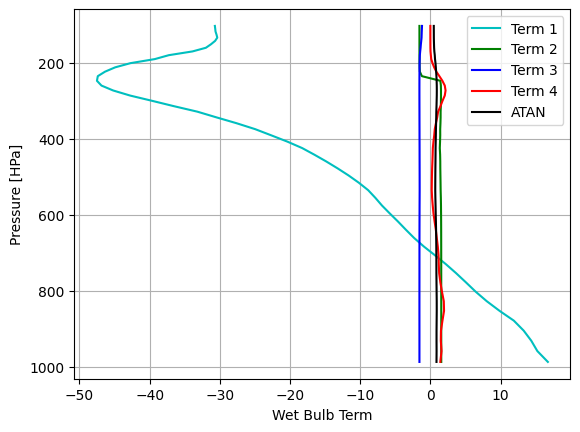

PUP idx =  (array([7]),)
PLO idx =  (array([0]),)

Gamma =  [6.579861]
Conditional Instability
Theta-e Gamma =  [-3.46479628]
Theta-e lapse rate is negative: potential instability
Tv Gamma =  [7.2036576]
Wetbulb Gamma =  [5.58811886]
Potential Instability
{'hght': array([  200.,   500.,   700.,  1000.,  1250.,  1500.,  1750.,  2000.,
        2250.,  2500.,  2700.,  3000.,  3200.,  3500.,  3750.,  4000.,
        4250.,  4500.,  4800.,  5000.,  5300.,  5700.,  6000.,  6200.,
        6500.,  6750.,  7000.,  7300.,  7700.,  8000.,  8250.,  8500.,
        8800.,  9000.,  9500.,  9800., 10000., 10500., 10750., 11000.,
       11500., 11750., 12000., 12500., 12800., 13250., 13500., 14000.,
       14500., 14750., 15250., 15500., 16000.]), 'pres': array([987.2, 958.6, 931.5, 904.9, 878.6, 852.8, 827.4, 802.4, 777.8,
       753.6, 729.9, 706.6, 683.7, 661.2, 639.1, 617.5, 596.3, 575.5,
       555.2, 535.2, 515.7, 496.6, 478. , 459.7, 441.9, 424.5, 407.5,
       390.9, 374.7, 359. , 343.6, 328.7, 

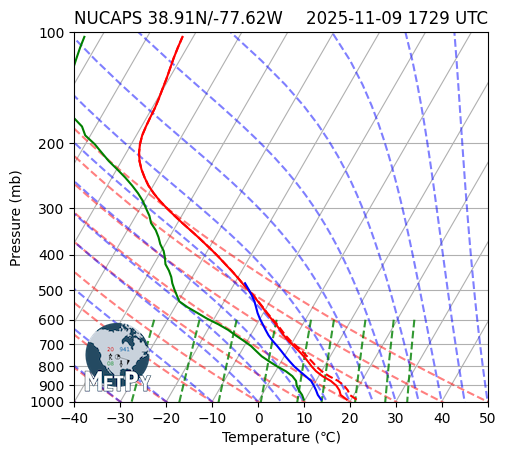

In [18]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from netCDF4 import Dataset
import h5py
from six import StringIO
import metpy.calc as mpcalc
from metpy.cbook import get_test_data
from metpy.plots import add_metpy_logo, SkewT
from metpy.units import units

'''
NOAA-20 NUCAPS Profile at 1729 UTC 9 November 2025 38.9N/-77.6W Retrieval #
'''

def read_nprovs_names(ncf):
    nc_fid = Dataset(ncf, 'r')
    names = nc_fid.variables.keys()
    nc_fid.close()
    return names

nprovs_ret_file = 'nprovs_20251109.nc'
names = read_nprovs_names(nprovs_ret_file)
print(names)

# Open file.
FILE_NAME = 'nprovs_20251109.nc'
temperature = '/20251109/NUCAPS_NOAA20_605/temperature'
pressure = '/20251109/NUCAPS_NOAA20_605/pressure'
humidity = '/20251109/NUCAPS_NOAA20_605/relative_humidity'
qf = '/20251109/NUCAPS_NOAA20_605/retrieval_quality_flag'
LATITUDE = '/20251109/NUCAPS_NOAA20_605/latitude'
LONGITUDE = '/20251109/NUCAPS_NOAA20_605/longitude'
time = '/20251109/NUCAPS_NOAA20_605/time'

with h5py.File(FILE_NAME, mode='r') as f:
    # List available datasets.
    print(f.keys())

    # Read dataset.
    temp = f[temperature]
    temp_ret = temp[:,:]
    print("Temp: ",temp_ret,temp_ret.shape)
    press = f[pressure]
    press_ret = press[:,:]
    print("Press: ",press_ret,press_ret.shape)
    RH = f[humidity]
    RH_ret = RH[:,:]
    print("Humidity: ",RH_ret,RH_ret.shape)
    rqf = f[qf]
    retqual = rqf[1048]
    if (retqual == 0):
        print("Retrieval value = 0: Accepted")
    elif (retqual == 1):
        print("Retrieval value = 1: rejected physical")
    elif (retqual == 2):
        print("Retrieval value = 2: rejected MIT")
    elif (retqual == 9):
        print("Retrieval value = 9: rejected physical and MIT")
    else:
        print("Retrieval rejected")        
    latitude = f[LATITUDE]
    for i, name in enumerate(latitude):
        if name > 37 and name < 40:
            print(f"Index {i}: {name}")
    lat = latitude[1048]
    print("Latitude: ",lat)
    longitude = f[LONGITUDE]
    for i, name in enumerate(longitude):
        if name > -79 and name < -75:
            print(f"Index {i}: {name}")
    lon = longitude[1048]
    print("Longitude: ",lon)
    time = f[time]
    for i, name in enumerate(time):
        if name > 173000.0 and name < 183000.0:
            print(f"Index {i}: {name}")
    time_ret = time[1048]
    print("Time: ",time_ret)    

print("Pressure: ",press_ret,press_ret.shape)
press = press_ret[1048,43:96]
print("Pressure retrieval: ",press,press.shape)
press = press[::-1]
print("Pressure: ",press,press.shape)

print("Temperature: ",temp_ret,temp_ret.shape)
temp = temp_ret[1048,43:96]
print("Temperature retrieval: ",temp,temp.shape)
temp = temp[::-1]
print("Temperature: ",temp,temp.shape)

print("Humidity: ", RH_ret)
RH = RH_ret[1048,43:96]
print("Humidity retrieval: ",RH,RH.shape)
RH_pct = RH[::-1]
print("Humidity: ",RH_pct,RH_pct.shape)
temperature_c = temp - 273.15
dewpoint_c = 243.04*((np.log(RH_pct/100))+((17.625*temperature_c)/(243.04+temperature_c)))/(17.625-(np.log(RH_pct/100))-((17.625*temperature_c)/(243.04+temperature_c)))
dewpoint = dewpoint_c + 273.15
print(dewpoint,dewpoint.shape)
height_km = np.array([0.2,0.5,0.7,1.0,1.25,1.5,1.75,2.0,2.25,2.5,2.7,3.0,3.2,3.5,3.75,4.0,4.25,4.5,4.8,5.0,5.3,5.7,6.0,
                      6.2,6.5,6.75,7.0,7.3,7.7,8.0,8.25,8.5,8.8,9.0,9.5,9.8,10.0,10.5,10.75,11.0,11.5,11.75,12.0,12.5,
                      12.8,13.25,13.5,14.0,14.5,14.75,15.25,15.5,16.0])
height_m = height_km * 1000
print(height_m,len(height_m))
height_km = height_m/1000
print(height_km,len(height_km))
pressure_pa = press
pressure_pa_r = np.flip(pressure_pa)
idx_500hpa = np.where(press == 496.6)
print("500 Hpa idx = ", idx_500hpa)
L_vapor = 2500

thetae = (273.15 + temperature_c)*((1000/pressure_pa)**0.286)+(3 * (RH_pct * (3.884266 * 10**
         ((7.5 * temperature_c)/(237.7 + temperature_c)))/100))
print("Theta-e: ", thetae, thetae.shape)
RH_pct = np.float64(RH_pct)
wetbulb = temperature_c*(np.arctan(0.151977*((RH_pct+8.313659)**0.5))) + (np.arctan(temperature_c+RH_pct)) - (np.arctan(RH_pct-1.676331))+((0.00391838*(RH_pct**1.5))*(np.arctan(0.023101*RH_pct))) - 4.686035
wetbulb[23:54] = np.nan
print("Wet bulb: ", wetbulb, wetbulb.shape)
WBD = temperature_c - wetbulb
satmixrat = (6.11*(10**((7.5*temperature_c)/(237.7+temperature_c))))/1000
print("Sat_mix_ratio = ",satmixrat)
mixrat = (6.11*(10**((7.5*dewpoint_c)/(237.7+dewpoint_c))))/1000
print("Mix_ratio = ",mixrat)
thetaw = thetae - (L_vapor*mixrat)
tempvirt = temp*(1+(0.61*(mixrat)))
tempvirt_c = tempvirt - 273.15
print("Virtual Temperature (C) = ",tempvirt_c)
tempvirt_exc = tempvirt_c - temperature_c

WB_term1 = temperature_c*(np.arctan(0.151977*((RH_pct+8.313659)**0.5)))
WB_term2 = np.arctan(temperature_c+RH_pct)
WB_term3 = -1*(np.arctan(RH_pct-1.676331))
WB_term4 = (0.00391838*(RH_pct**1.5))*(np.arctan(0.023101*RH_pct))
ATAN_term1 = (np.arctan(0.151977*((RH_pct+8.313659)**0.5)))

plt.plot(height_km, pressure_pa, color='black', label='Height')
plt.scatter(height_km, pressure_pa, color='black', marker='x')
plt.gca().invert_yaxis()
plt.xlabel("Height [km]")
plt.ylabel("Pressure [HPa]")
plt.legend()
plt.grid()
plt.show()
print("Height:", height_km)
print("Pressure:", pressure_pa)

plt.plot(RH_pct, pressure_pa, 'g-', label='RH')
plt.scatter(RH_pct, pressure_pa, color='green', marker='x')
plt.gca().invert_yaxis()
plt.xlabel("Humidity [%]")
plt.ylabel("Pressure [HPa]")
plt.legend()
plt.grid()
plt.show()

plt.plot(wetbulb, pressure_pa, 'c-', label='Wetbulb')
plt.scatter(wetbulb, pressure_pa, color='cyan', marker='x')
plt.plot(temperature_c, pressure_pa, 'r-', label='Temperature')
plt.gca().invert_yaxis()
plt.xlabel("Temperature [C]")
plt.ylabel("Pressure [HPa]")
plt.legend()
plt.grid()
plt.show()

plt.plot(WB_term1, pressure_pa, 'c-', label='Term 1')
plt.plot(WB_term2, pressure_pa, 'g-', label='Term 2')
plt.plot(WB_term3, pressure_pa, 'b-', label='Term 3')
plt.plot(WB_term4, pressure_pa, 'r-', label='Term 4')
plt.plot(ATAN_term1, pressure_pa, 'k-', label='ATAN')
plt.gca().invert_yaxis()
plt.xlabel("Wet Bulb Term")
plt.ylabel("Pressure [HPa]")
plt.legend()
plt.grid()
plt.show()

idx_pup = np.where(press == 802.4)
idx_plo = np.where(press == 987.2)
print("PUP idx = ", idx_pup)
print("PLO idx = ", idx_plo)
Z_upper = height_km[idx_pup]
Z_lower = height_km[idx_plo]
T_sfc = temp[idx_plo]
T_top = temp[idx_pup]
Te_sfc = thetae[idx_plo]
Te_top = thetae[idx_pup]
Tv_sfc = tempvirt_c[idx_plo]
Tv_top = tempvirt_c[idx_pup]
wetbulb_sfc = wetbulb[idx_plo]
wetbulb_top = wetbulb[idx_pup]
thetaw_sfc = thetaw[idx_pup]
delta_z = 1800
delta_zkm = 1.8
gamma = (T_sfc - T_top)/(delta_zkm)
gamma_Te = (Te_sfc - Te_top)/(Z_lower - Z_upper)
gamma_Tv = (Tv_sfc - Tv_top)/(delta_zkm)
gamma_wb = (wetbulb_sfc - wetbulb_top)/(delta_zkm)

print("")
print("Gamma = ", gamma)
if gamma > 4.8 and gamma <= 9.8:
    print("Conditional Instability") 
elif gamma > 9.8:
    print("Absolute Instability")
print("Theta-e Gamma = ", gamma_Te)
if gamma_Te < 0:
    print("Theta-e lapse rate is negative: potential instability")    
print("Tv Gamma = ", gamma_Tv)
print("Wetbulb Gamma = ", gamma_wb)
if gamma_wb > 4.8:
    print("Potential Instability")    
 
mydata=dict(zip(('hght','pres','temp','dwpt','thtae','thetaw','wetbulb','depression','tempvirt','tempvirt_exc'),(height_m,pressure_pa,temperature_c,dewpoint_c,thetae,thetaw,wetbulb,WBD,tempvirt_c,tempvirt_exc)))
print(mydata)
df_ret = pd.DataFrame.from_dict(mydata)
print(df_ret)
wdir = []
wspd = []
wval = -9999.00
data_len = len(df_ret)
print("DF Length = ", data_len)
for i in range(data_len):
    wdir.append(wval)
    wspd.append(wval)
print("wdir, wspd: ", wdir, wspd)
data_sharppy=dict(zip(('pres','hght','temp','dwpt','wetbulb'),(pressure_pa, height_m, temperature_c, dewpoint_c, wetbulb)))
print(data_sharppy)
df_sharppy = pd.DataFrame.from_dict(data_sharppy)
print(df_sharppy)
df_sharppy = df_sharppy[['pres', 'hght', 'temp', 'dwpt', 'wetbulb']]
print(df_sharppy)
df_sharppy_file = df_sharppy[['pres', 'hght', 'temp', 'dwpt']]
print(df_sharppy_file)
df_sharppy_wind = df_sharppy_file.assign(wdir = wdir, wspd = wspd)
print(df_sharppy_wind)
print("")
print("Sharppy formatted retrieval: ")
print("")
print(df_sharppy_wind.to_string(header=False, index=False, formatters={"pres": "  {:.2f},  ".format, "hght": "{:.2f},  ".format,
                                                                       "temp": "{:.2f},  ".format, "dwpt": "{:.2f},  ".format,
                                                                       "wdir": "{:.2f},  ".format, "wspd": "{:.2f} ".format}))
print("")
print("Sounding profile with virtual temperature")
print("")
data_sharppy=dict(zip(('pres','hght','tempvirt','dwpt','wetbulb'),(pressure_pa, height_m, tempvirt_c, dewpoint_c, wetbulb)))
print(data_sharppy)
df_sharppy = pd.DataFrame.from_dict(data_sharppy)
print(df_sharppy)
df_sharppy = df_sharppy[['pres', 'hght', 'tempvirt', 'dwpt', 'wetbulb']]
print(df_sharppy)
df_sharppy_file = df_sharppy[['pres', 'hght', 'tempvirt', 'dwpt']]
print(df_sharppy_file)
df_sharppy_wind =df_sharppy_file.assign(wdir = wdir, wspd = wspd)
print(df_sharppy_wind)
print("")
print("Sharppy formatted retrieval: ")
print("")
print(df_sharppy_wind.to_string(header=False, index=False, formatters={"pres": "  {:.2f},  ".format, "hght": "{:.2f},  ".format,
                                                                       "tempvirt": "{:.2f},  ".format, "dwpt": "{:.2f},  ".format,
                                                                       "wdir": "{:.2f},  ".format, "wspd": "{:.2f} ".format}))
print("")

mydata=dict(zip(('hght','pres','temp','dwpt','thtae','thetaw','wetbulb','depression','tempvirt','tempvirt_exc'),(height_m,pressure_pa,temperature_c,dewpoint_c,thetae,thetaw,wetbulb,WBD,tempvirt_c,tempvirt_exc)))
print(mydata)
df_ret = pd.DataFrame.from_dict(mydata)
print(df_ret)
wdir = []
wspd = []
wval = 0
data_len = len(df_ret)
print("DF Length = ", data_len)
for i in range(data_len):
    wdir.append(wval)
    wspd.append(wval)
print("wdir, wspd: ", wdir, wspd)
data_sharppy=dict(zip(('pres','hght','temp','dwpt','wetbulb'),(pressure_pa, height_m, temperature_c, dewpoint_c, wetbulb)))
print(data_sharppy)
df_sharppy = pd.DataFrame.from_dict(data_sharppy)
print(df_sharppy)
df_sharppy = df_sharppy[['pres', 'hght', 'temp', 'dwpt', 'wetbulb']]
print(df_sharppy)
df_sharppy_T = df_sharppy[['pres', 'hght', 'temp', 'dwpt', 'wetbulb']]
print(df_sharppy_T)
df_sharppy_file = df_sharppy[['pres', 'hght', 'temp', 'dwpt']]
print(df_sharppy_file)
df_sharppy_wind =df_sharppy_file.assign(wdir = wdir, wspd = wspd)
print(df_sharppy_wind)
print("")
print("Sharppy formatted retrieval: ")
print("")
print(df_sharppy_wind.to_string(header=False, index=False, formatters={"pres": "  {:.2f},  ".format, "hght": "{:.2f},  ".format,
                                                                       "temp": "{:.2f},  ".format, "dwpt": "{:.2f},  ".format,
                                                                       "wdir": "{:.2f},  ".format, "wspd": "{:.2f} ".format}))

print("")
print("Sounding profile with virtual temperature")
print("")
data_sharppy=dict(zip(('pres','hght','tempvirt','dwpt','wetbulb'),(pressure_pa, height_m, tempvirt_c, dewpoint_c, wetbulb)))
print(data_sharppy)
df_sharppy = pd.DataFrame.from_dict(data_sharppy)
print(df_sharppy)
df_sharppy = df_sharppy[['pres', 'hght', 'tempvirt', 'dwpt', 'wetbulb']]
print(df_sharppy)
df_sharppy_Tv = df_sharppy[['pres', 'hght', 'tempvirt', 'dwpt', 'wetbulb']]
print(df_sharppy_Tv)
df_sharppy_file = df_sharppy[['pres', 'hght', 'tempvirt', 'dwpt']]
print(df_sharppy_file)
df_sharppy_wind =df_sharppy_file.assign(wdir = wdir, wspd = wspd)
print(df_sharppy_wind)
print("")
print("Sharppy formatted retrieval: ")
print("")
print(df_sharppy_wind.to_string(header=False, index=False, formatters={"pres": "  {:.2f},  ".format, "hght": "{:.2f},  ".format,
                                                                       "tempvirt": "{:.2f},  ".format, "dwpt": "{:.2f},  ".format,
                                                                       "wdir": "{:.2f},  ".format, "wspd": "{:.2f} ".format}))
print("")
P_level_upper = pressure_pa[idx_pup]
P_level_lower = pressure_pa[idx_plo]
Z_upper = height_km[idx_pup]
Z_lower = height_km[idx_plo]
T_upper = temperature_c[idx_pup]
T_lower = temperature_c[idx_plo]
Tv_upper = tempvirt_c[idx_pup]
Tv_lower = tempvirt_c[idx_plo]
TD_upper = dewpoint_c[idx_pup]
TD_lower = dewpoint_c[idx_plo]
CAPE = 0

print("Dry bulb temperature calculation")
print("")
def MWPI(P_level_upper, P_level_lower, Z_upper, Z_lower, T_upper, T_lower, TD_upper, TD_lower, CAPE):
        gamma = (T_lower - T_upper)/(Z_upper - Z_lower)
        print("Gamma = ", gamma)
        DD_upper = T_upper - TD_upper
        print("DD upper = ", DD_upper)
        DD_lower = T_lower - TD_lower
        print("DD lower = ", DD_lower)
        DDD = DD_lower - DD_upper
        print("Delta DD = ", DDD)
        MWPI = (CAPE/1000) + (gamma/5) + (DDD/5)
        WGP = (0.35435365777 * (MWPI**2)) + (1.2959855*MWPI) + 33.8176788
        return MWPI, WGP
MWPI, WGP = MWPI(P_level_upper, P_level_lower, Z_upper, Z_lower, T_upper, T_lower, TD_upper, TD_lower, CAPE)    
print("")
print("MWPI = ", MWPI)
print("MWPI WGP (kt) = ", WGP)
print("")
print("Virtual temperature calculation")
print("")
def MWPI_Tv(P_level_upper, P_level_lower, Z_upper, Z_lower, Tv_upper, Tv_lower, TD_upper, TD_lower, CAPE):
        gamma = (Tv_lower - Tv_upper)/(Z_upper - Z_lower)
        print("Gamma = ", gamma)
        DD_upper = Tv_upper - TD_upper
        print("DD upper = ", DD_upper)
        DD_lower = Tv_lower - TD_lower
        print("DD lower = ", DD_lower)
        DDD = DD_lower - DD_upper
        print("Delta DD = ", DDD)
        MWPI_Tv = (CAPE/1000) + (gamma/5) + (DDD/5)
        WGP_Tv = (0.35435365777 * (MWPI_Tv**2)) + (1.2959855*MWPI_Tv) + 33.8176788
        return MWPI_Tv, WGP_Tv
MWPI_Tv, WGP_Tv  = MWPI_Tv(P_level_upper, P_level_lower, Z_upper, Z_lower, Tv_upper, Tv_lower, TD_upper, TD_lower, CAPE)    
print("")
print("MWPI from Virtual Temperature:")
print("MWPI = ", MWPI_Tv)
print("MWPI WGP (kt) = ", WGP_Tv)

p = df_sharppy['pres'].values * units.hPa
T = df_sharppy_T['temp'].values * units.degC
Tv = df_sharppy_Tv['tempvirt'].values * units.degC
Tw = df_sharppy['wetbulb'].values * units.degC
Td = df_sharppy['dwpt'].values * units.degC

skew = SkewT()

# Plot the data using normal plotting functions, in this case using
# log scaling in Y, as dictated by the typical meteorological plot
skew.plot(p, T, 'r')
skew.plot(p, Tv, color='red', linestyle='--')
skew.plot(p, Td, 'g')
skew.plot(p, Tw, 'b')

# Set some better labels than the default
skew.ax.set_xlabel('Temperature (\N{DEGREE CELSIUS})')
skew.ax.set_ylabel('Pressure (mb)')

# Add the relevant special lines
skew.plot_dry_adiabats()
skew.plot_moist_adiabats()
skew.plot_mixing_lines()
skew.ax.set_ylim(1000, 100)

# Add the MetPy logo!
fig = plt.gcf()
add_metpy_logo(fig, 80, 60)

# Add some titles
plt.title('NUCAPS 38.91N/-77.62W', loc='left')
plt.title('2025-11-09 1729 UTC', loc='right')
plt.savefig('skewt_noaa20_1109_1729_mp.png', bbox_inches='tight') # saves the plot to the disk.
plt.show()